# Implementacion de modelo Hodgkin-Huxley

Se implementa el modelo H-H en python, solicion en un punto de las ecuaciones 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hh_equations import a_n, b_n, a_m, b_m, a_h, b_h

#plt.style.use('classic')  # Puedes probar otros estilos como 'ggplot' 'bmh', 'classic', etc.


/Users/fabiancastano/Documents/GitHub/SignalProcessingPrjs/Signal_Processing/22_Fitzhut_Nagumo/HH_Model/hh_equations.py:5: RuntimeWarning: invalid value encountered in divide
  return (0.01*(v+55))/(1-exp(-(v+55)/10))
/Users/fabiancastano/Documents/GitHub/SignalProcessingPrjs/Signal_Processing/22_Fitzhut_Nagumo/HH_Model/hh_equations.py:9: RuntimeWarning: invalid value encountered in divide
  return (0.1*(v+40))/(1-exp(-(v+40)/10))


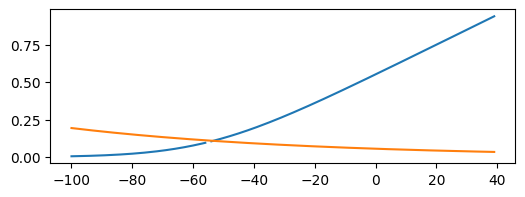

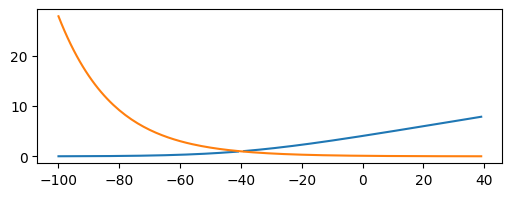

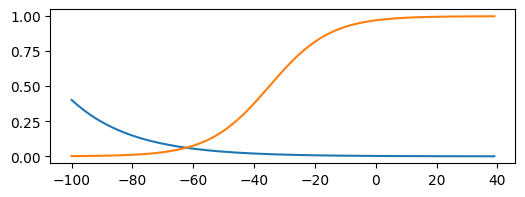

In [12]:
v = np.arange(-100, 40, 1)

an = a_n(v)
bn = b_n(v)
am = a_m(v)
bm = b_m(v)
ah = a_h(v)
bh = b_h(v)


plt.figure(figsize=(6,2))
plt.plot(v, an)
plt.plot(v, bn)

plt.figure(figsize=(6,2))
plt.plot(v, am)
plt.plot(v, bm)

plt.figure(figsize=(6,2))
plt.plot(v, ah)
plt.plot(v, bh)

In [20]:
# Constants for the method
Cm = 1                     # membrane capacitance uF/cm^2
dt = 0.01                  # delta time in ms
t = np.arange(0, 60, dt)   # time array in ms

I = 15  # external current applyed

ENa=50      # mv Na reversal potential 
EK=-77      # mv K reversal potential 
El=-54.4    # mv Leakage reversal potential 
gbarNa=120  # mS/cm^2 Na conductance 
gbarK=36    # mS/cm^2 K conductance 
gbarl=0.3   # mS/cm^2 Leakage conductance
V_rest = -60

n = np.zeros(len(t))
m = np.zeros(len(t))
h = np.zeros(len(t))
V = np.zeros(len(t))
V[0] = np.array(V_rest)  # Valor inicial de la solucion

m[0] = a_m(V[0])/(a_m(V[0])+b_m(V[0]))    # Initial m-value
n[0] = a_n(V[0])/(a_n(V[0])+b_n(V[0]))    # Initial n-value
h[0] = a_h(V[0])/(a_h(V[0])+b_h(V[0]))    # Initial h-value


for i in range(0, len(t) - 1):

    # Euler method
    m[i+1]= m[i]+dt*((a_m(V[i])*(1-m[i]))-(b_m(V[i])*m[i]))
    n[i+1]= n[i]+dt*((a_n(V[i])*(1-n[i]))-(b_n(V[i])*n[i])) 
    h[i+1]= h[i]+dt*((a_h(V[i])*(1-h[i]))-(b_h(V[i])*h[i])) 
    
    gNa=gbarNa*h[i]*m[i]**3
    gK=gbarK*n[i]**4
    gl=gbarl
    
    INa=gNa*(V[i]-ENa)
    IK=gK*(V[i]-EK)
    Il=gl*(V[i]-El)
    
    # Euler method to find the next voltage value
    V[i+1]=V[i]+(dt)*((1/Cm)*(I-(INa+IK+Il)))
    


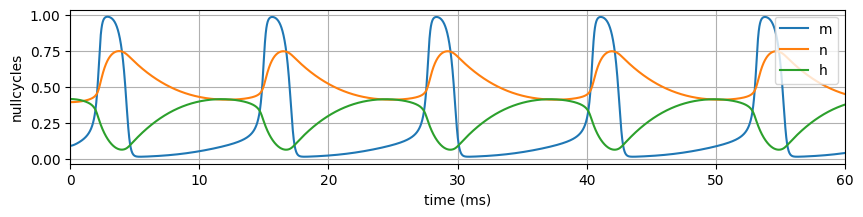

In [33]:
plt.figure(figsize=(10,2))
plt.plot(t, m)
plt.plot(t, n)
plt.plot(t, h)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend(["m", "n", "h"])
plt.xlabel('time (ms)')
plt.ylabel('nullcycles')
plt.xlim([0,60])
#plt.ylim([-80,40])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/nullcycles.pdf", format="pdf", bbox_inches="tight")


/var/folders/89/43ylvgyx5hj4v_z5nn_dl1980000gn/T/ipykernel_2574/2377796413.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


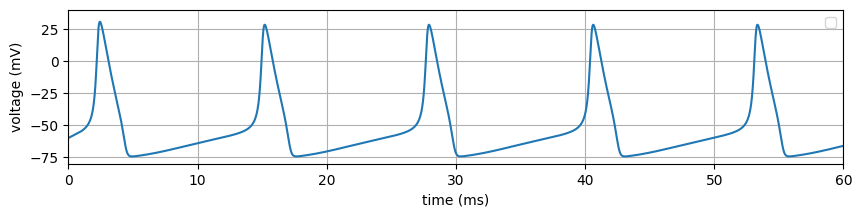

In [31]:
plt.figure(figsize=(10,2))
plt.plot(t, V)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.xlim([0,60])
plt.ylim([-80,40])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/HHResponse.pdf", format="pdf", bbox_inches="tight")
